In [60]:
Customer Life Value analytics - case study 
Case Study: E-commerce Store

Background:
ABC Electronics is an online retailer specializing in consumer electronics. 
They have been in operation for several years and have built a substantial customer base. 
ABC Electronics wants to understand the lifetime value of their customers to optimize their marketing strategies and improve customer retention.

Data Collection:
ABC Electronics collects various data points about their customers, including:

Customer demographics (age, gender, location, etc.)
Purchase history (transaction dates, order values, products purchased, etc.)
Website behavior (pages visited, time spent, etc.)
Customer interactions (customer service inquiries, feedback, etc.)

SyntaxError: invalid syntax (1161630590.py, line 1)

In [61]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-lifetime-value-analytics-case-study/customer_acquisition_data.csv


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [63]:

df = pd.read_csv('/kaggle/input/customer-lifetime-value-analytics-case-study/customer_acquisition_data.csv')
print(df)

     customer_id           channel       cost  conversion_rate  revenue
0              1          referral   8.320327         0.123145     4199
1              2  paid advertising  30.450327         0.016341     3410
2              3   email marketing   5.246263         0.043822     3164
3              4      social media   9.546326         0.167592     1520
4              5          referral   8.320327         0.123145     2419
..           ...               ...        ...              ...      ...
795          796      social media   9.546326         0.167592     2813
796          797   email marketing   5.246263         0.043822     3439
797          798      social media   9.546326         0.167592     2101
798          799  paid advertising  30.450327         0.016341      813
799          800   email marketing   5.246263         0.043822     4820

[800 rows x 5 columns]


# Data Cleaning & Preprocessing

In [64]:
df.describe()

,customer_id,cost,conversion_rate,revenue
count,800.0000,800.000000,800.000000,800.000000
mean,400.5000,13.148052,0.086305,2769.151250
std,231.0844,9.922337,0.059611,1259.543706
min,1.0000,5.246263,0.016341,500.000000
25%,200.7500,5.246263,0.043822,1694.000000
50%,400.5000,8.320327,0.043822,2764.000000
75%,600.2500,9.546326,0.123145,3824.250000
max,800.0000,30.450327,0.167592,4998.000000


In [65]:
df.isna().sum() #Missing value check

customer_id        0
channel            0
cost               0
conversion_rate    0
revenue            0
dtype: int64

In [66]:
df.duplicated().sum()#Duplicates

0

In [67]:
df.dtypes#Data types

customer_id          int64
channel             object
cost               float64
conversion_rate    float64
revenue              int64
dtype: object

In [68]:
df['conversion_rate'].describe()#Outlier detection

count    800.000000
mean       0.086305
std        0.059611
min        0.016341
25%        0.043822
50%        0.043822
75%        0.123145
max        0.167592
Name: conversion_rate, dtype: float64

# EDA

In [69]:
df['channel'].value_counts()
df['channel'].value_counts(normalize = True)

channel
email marketing     0.26750
referral            0.25875
paid advertising    0.24250
social media        0.23125
Name: proportion, dtype: float64

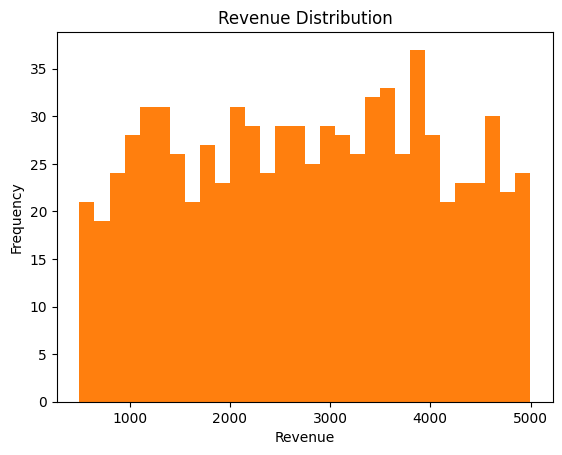

In [70]:
#revenue distribution
import matplotlib.pyplot as plt
plt.hist(df['revenue'], bins = 30)
plt.hist(df['revenue'], bins=30)
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

In [71]:
#channel level analysis
channel_sum = df.groupby('channel').agg({
    'customer_id':'count',
    'cost':'mean',
    'conversion_rate':'mean',
    'revenue': 'mean'
}).rename(columns = {'customer_id':'customer_count'})
channel_sum

,customer_count,cost,conversion_rate,revenue
channel,,,,
email marketing,214,5.246263,0.043822,2825.728972
paid advertising,194,30.450327,0.016341,2826.783505
referral,207,8.320327,0.123145,2751.458937
social media,185,9.546326,0.167592,2663.064865


Email marketing: with highest revenue and lowest cost; this channel is valuable
Paid Ads: high revene but worst ROI(highly cost compare with email)
Referral: high conversion rate, low cost with strong organic referrals and good revenue
Social media: highest conversion rate but lowest revenue with low price per customer

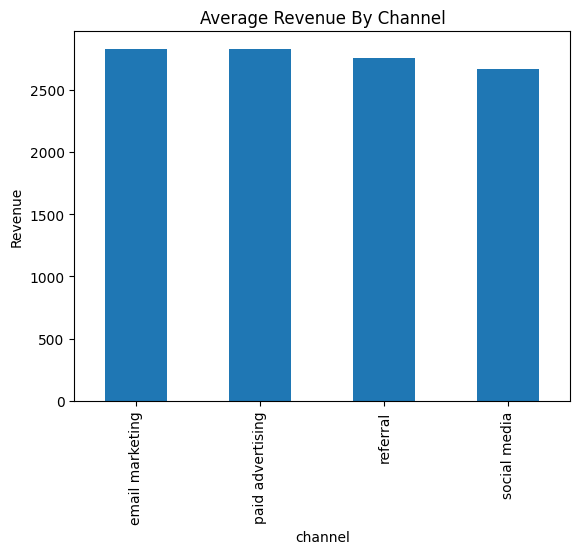

In [72]:
channel_sum['revenue'].plot(kind = 'bar')
plt.title('Average Revenue By Channel')
plt.ylabel('Revenue')
plt.show()

### conversion rate relationships
Do high-cost channels yield higher conversion rates?

Are there low-cost, high-conversion (high ROI) channels?

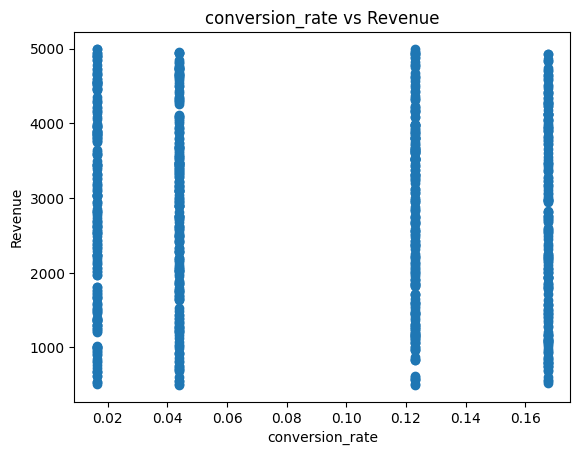

In [73]:
plt.scatter(df['conversion_rate'], df['revenue'])
plt.title('conversion_rate vs Revenue')
plt.xlabel('conversion_rate')
plt.ylabel('Revenue')
plt.show()

conversion rate is a channel level constant in this dataset 
revenue is a randomly distributed individual transaction value
no continuous relationship exists between revenue and conversion rate

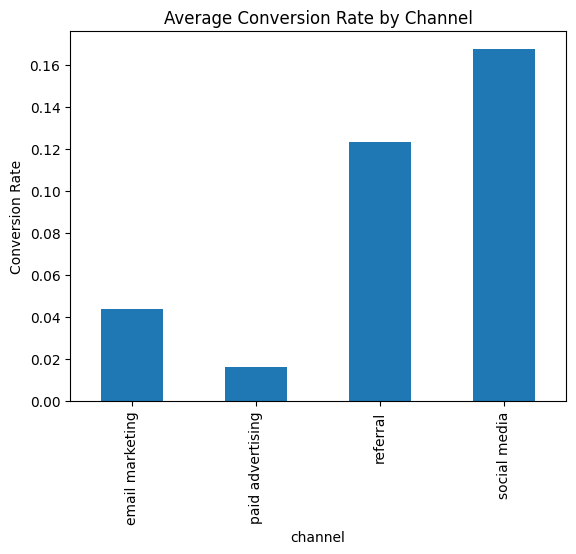

In [74]:
#Which channel has the highest conversion rate?
df.groupby('channel')['conversion_rate'].mean().plot(kind='bar')
plt.title('Average Conversion Rate by Channel')
plt.ylabel('Conversion Rate')
plt.show()

Paid Ads < Email marketing < Referral < Social Media

**Return on Investment (ROI)**

Return on Investment (ROI) is a financial metric used to evaluate the profitability and efficiency of an investment. It measures the return or gain generated from an investment relative to its cost.
        
        
        ROI = (Revenue - Cost) / Cost

In [75]:
df['ROI'] = (df['revenue']- df['cost']) / df['cost']
df.head()

,customer_id,channel,cost,conversion_rate,revenue,ROI
0,1,referral,8.320327,0.123145,4199,503.667681
1,2,paid advertising,30.450327,0.016341,3410,110.985660
2,3,email marketing,5.246263,0.043822,3164,602.095925
3,4,social media,9.546326,0.167592,1520,158.223564
4,5,referral,8.320327,0.123145,2419,289.733775


**CLV** 

Dataset doesnot contain order history or retention info, CLV(AOV * Frequency * Lifespan) cannot be used.
Then here's the single- period profit-based CLV estimate: 

    CLV = Expected Revenue * Conversion Rate - Acquisition Cost 
which allows to evaluate mkting channel profitability and customer level ROI even without full purchase history

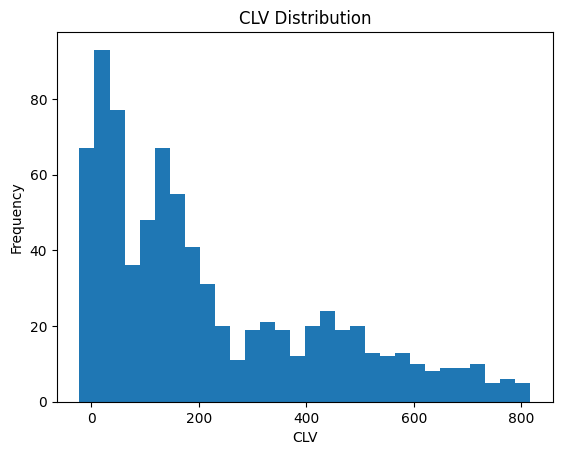

In [76]:
df['CLV'] = df['revenue'] * df['conversion_rate'] - df['cost']

plt.hist(df['CLV'], bins = 30)
plt.title('CLV Distribution')
plt.ylabel('Frequency')
plt.xlabel('CLV')
plt.show()

Left-side CLV == 0, acquisition cost higher or conversion rate low

Middle(100-300) mostly from email/referral

Right-side(400-800) customers with high-revenue and high conversion rate

Social media + referral have high clv cluster

# Segmentation Analysis

ABC Electronics segments their customers into three groups based on CLV:

High-Value Customers: Customers with CLV in the top 20% percentile. These customers generate the most revenue for the business.

Medium-Value Customers: Customers with CLV in the middle 60% percentile. These customers contribute to the overall revenue and have decent long-term potential.

Low-Value Customers: Customers with CLV in the bottom 20% percentile. These customers have low spending patterns and may require additional nurturing to increase their CLV.

In [77]:
#segment method: 20-60-20
df['segment'] = pd.qcut(df['CLV'], q = [ 0, 0.2, 0.8, 1.0],
                       labels = ['Low Value', 'Medium Value', 'High Value']) #top 20% - High, Middel 60% - Medium, bottom 20% - low value

In [78]:
#segment describe
df.groupby('segment')[['CLV','revenue','cost']].mean()

/tmp/ipykernel_48/3233571972.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('segment')[['CLV','revenue','cost']].mean()


,CLV,revenue,cost
segment,,,
Low Value,8.357001,2139.812500,28.244972
Medium Value,176.098694,2586.922917,9.490004
High Value,573.642980,3945.175000,9.025276


High Value customers(top 20%)

    With highest average of CLV, typically originating from social media and referrals,

    Higher revenue with lower costs(high ROI)  -- >  Higher conversion rate than other segments

Medium Value(middle 60%)

    Moderate revenue and costs

    Combination of customers from all channels

Low Value(Bottom 20%)

    Primarily frim pad=id ads(high cost but low conversion)

    Lower revenue, significantly lower CLV

    High churn risk, worst ROI users

/tmp/ipykernel_48/478099527.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('segment')['CLV'].mean().plot(kind='bar')


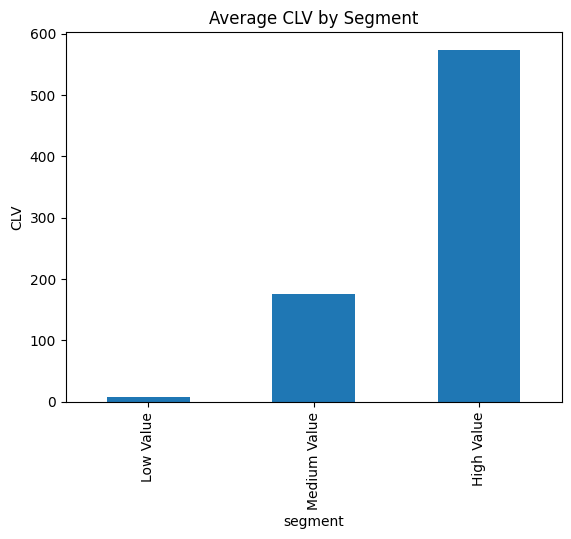

In [79]:
df.groupby('segment')['CLV'].mean().plot(kind='bar')
plt.title('Average CLV by Segment')
plt.ylabel('CLV')
plt.show()

/tmp/ipykernel_48/182711830.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby(['segment','channel']).size() /
/tmp/ipykernel_48/182711830.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('segment').size()).unstack().plot(kind='bar', stacked=True)


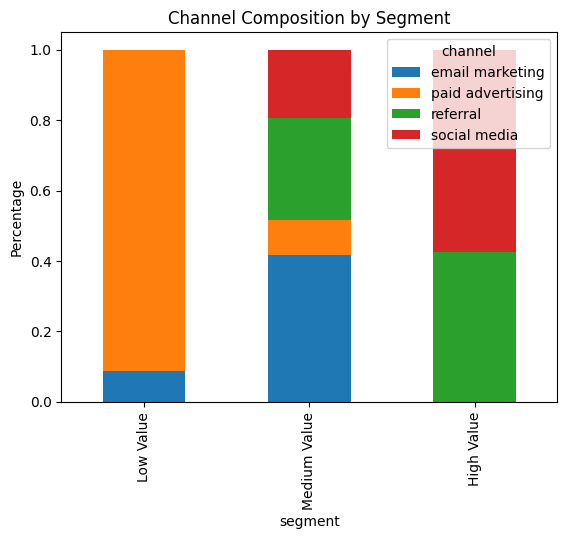

In [80]:
(df.groupby(['segment','channel']).size() /
 df.groupby('segment').size()).unstack().plot(kind='bar', stacked=True)
plt.title('Channel Composition by Segment')
plt.ylabel('Percentage')
plt.show()

Low Value high composition from paid ads

High Value from referral and social media

Objectives:

1.Calculate the customer lifetime value for different segments of customers.

2.Identify the most valuable customer segments.

3.Develop personalized marketing strategies to increase customer retention and maximize CLV.

High value customer(Top 20%): Continuously increase investment in referrals and social media;rayal plan and increase repurchase

    From referrals and social media channels
    highest conversion rate(> 0.12)
    More respinsive to content markting and user reviews

Medium value customer(Middle 60%)：Focus onstengthening email marketing retargeting

    Cover all chanels with even distributions
    Considered cultivatable prospects

Low value customer(Bottom 20%):Reduce paid ads budget or adjust compaign strategy

    Low revenue contribution, minimal profit margin
    

#  Modeling

In [81]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np

In [82]:
#Linear Regression
X= df[['cost', 'conversion_rate', 'channel']]
y = df['revenue']

X = pd.get_dummies(X, columns=['channel'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state = 42)
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

print("R² score:", model_lr.score(X_test, y_test))
print("Coefficients:")
for name, coef in zip(X.columns, model_lr.coef_):
    print(f"{name}: {coef}")

R² score: -0.021139505374697
Coefficients:
cost: -1.830054765830466
conversion_rate: -35.12204489400108
channel_paid advertising: 47.87502168614631
channel_referral: -106.72695452534902
channel_social media: -204.73882707249211


Relationship between revenue and variables may not linear, then regression cannot be used for prediction

In [83]:
#Random Forest - feature importance
from sklearn.ensemble import RandomForestRegressor
X = df[['cost', 'conversion_rate', 'CLV', 'channel']]
y = df['revenue']

X = pd.get_dummies(X, columns=['channel'], drop_first=True)

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_

for name, val in zip(X.columns, importances):
    print(f"{name}: {val:.4f}")

cost: 0.0427
conversion_rate: 0.1589
CLV: 0.7436
channel_paid advertising: 0.0423
channel_referral: 0.0064
channel_social media: 0.0062


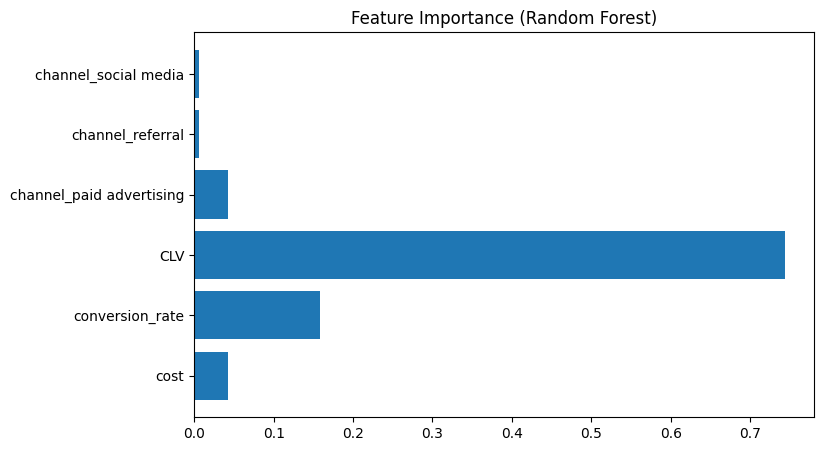

In [84]:
plt.figure(figsize=(8,5))
plt.barh(X.columns, importances)
plt.title('Feature Importance (Random Forest)')
plt.show()

CLV is the most critical growth driver
The impact of channel selection is far less significant than customer quality itself

In [85]:
#K-means cluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = df[['CLV', 'cost', 'conversion_rate']]
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled)
df.groupby('cluster')[['CLV','cost','conversion_rate','revenue']].mean()

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,CLV,cost,conversion_rate,revenue
cluster,,,,
0,121.205065,5.847208,0.059329,2496.075188
1,418.684052,8.987414,0.147330,2949.908824
2,15.743532,30.450327,0.016341,2826.783505


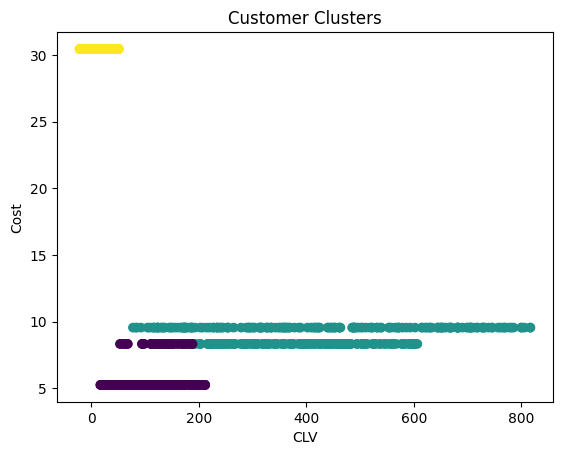

In [86]:
plt.scatter(df['CLV'], df['cost'], c=df['cluster'])
plt.xlabel('CLV')
plt.ylabel('Cost')
plt.title('Customer Clusters')
plt.show()

# Recommendations

Cluster1(Highest CLV, conversion rate and revenue, low cost) -- VIP segment
    
    increase budget, 
    personalize content, 
    offer loalty program 
    strengthen remarketing

Cluster 2(Moderate CLV, low cost, decent revenue) -- developable segment

    Increase email marketing frequency
    Upsell/cross-sell
    A/B test conversion funnel

Cluster 3(Low value, high cost group) -- loss segment

    Worst ROI reduce budget allocation -- tighten targeting
    Optimize ad delivery
    Target more precise audiences
    
    
